In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os
from langchain_mistralai import ChatMistralAI

In [43]:
import os
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI

# 1. Force reload the environment variables from your .env file
load_dotenv()

# 2. Get your key using your specific key name
api_key = os.getenv("mistral_APIKEY")

# 3. Explicitly pass it using the 'mistral_api_key' argument
model = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7,
    mistral_api_key=api_key  # <-- Crucial fix!
)

In [64]:
class BlogState(TypedDict):
    topic:str
    title:str
    outline:str
    blog:str
    evaluate:int
    feedback:list[str]

In [70]:
graph = StateGraph(BlogState)
#node
graph.add_node("create_outline", create_outline)
#node
graph.add_node("create_blog", create_blog)
graph.add_node("evaluate", evaluate)
#edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog" , "evaluate")
graph.add_edge("evaluate", END)
#compile
workflow = graph.compile()

In [66]:
def create_outline(state:BlogState)->BlogState:
    title = state['title']
    prompt = f"Create a detailed outline for a blog post with the title: {title}"
    response = model.invoke(prompt).content
    state['outline'] = response
    return state

In [67]:
def create_blog(state:BlogState)->BlogState:
    outline = state["outline"]
    title = state["title"]
    prompt = f"write a blog post based title - {title} using the following outline: {outline}\n\n blog post:"
    response = model.invoke(prompt).content
    state['blog'] = response
    return state
    

In [82]:
initial_state = BlogState(topic="AI" , title="the future of Ai" , outline="" , evaluate=0 , feedback=[])
final_state=workflow.invoke(initial_state)
print(final_state)

{'topic': 'AI', 'title': 'the future of Ai', 'outline': '# **Blog Post Outline: The Future of AI**\n\n## **Title:** *The Future of AI: Trends, Challenges, and Transformative Impacts*\n\n## **Introduction**\n- **Hook:** Start with a thought-provoking question or statistic (e.g., *"By 2030, AI could contribute up to $15.7 trillion to the global economy—how will it reshape our world?"*)\n- **Brief overview of AI’s current state:** Mention key advancements (e.g., generative AI, deep learning, automation).\n- **Thesis statement:** AI is evolving rapidly, and its future will bring unprecedented opportunities, ethical dilemmas, and societal shifts.\n\n---\n\n## **Section 1: The Evolution of AI – Where Are We Now?**\n### **1.1 A Brief History of AI**\n- Early AI (1950s–1980s): Rule-based systems, symbolic AI.\n- The AI Winter (1990s–2000s): Funding cuts, slow progress.\n- The Deep Learning Revolution (2010s–present): Neural networks, big data, and breakthroughs like AlphaGo, GPT, and DALL·E.\n

In [80]:
def evaluate(state:BlogState)->BlogState:
    blog = state['blog']
    topic = state['topic']
    prompt = f"Evaluate the quality of the following blog post about {topic} and provide feedback for improvement:\n\n{blog}\n\nFeedback:"
    response = model.invoke(prompt).content
    state["feedback"] = response 
    return state

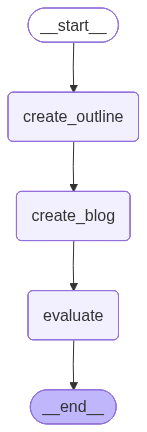

In [74]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [81]:
print(final_state['evaluate'])

0
